In [1]:
from utils import load_it_data, visualize_img
import matplotlib.pyplot as plt
import numpy as np
import gdown

path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import timm
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_squared_error

print("is working")

import timm
import torch
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader


from torch.utils.data import DataLoader, TensorDataset
import torch
import torchvision.models as models
from torchvision import transforms
import numpy as np
from sklearn.decomposition import PCA
from utils import load_it_data, visualize_img, save_pkl, load_pkl


stimulus_train_tensor = torch.from_numpy(stimulus_train).float()

dataset = TensorDataset(stimulus_train_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

stimulus_val_tensor = torch.from_numpy(stimulus_val).float()
dataset_val = TensorDataset(stimulus_val_tensor)
dataloader_val = DataLoader(dataset_val, batch_size=32, shuffle=False)

# Load a pre-trained EfficientNet model
efficientnet = models.efficientnet_b0(pretrained=True)

is working


/home/ralmeida/miniconda3/envs/nx414/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ralmeida/miniconda3/envs/nx414/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Processing conv_stem...
Mean squared error (linear regression): 0.13046833872795105
Mean squared error (ridge regression): 0.12016607820987701
Mean explained variance (linear regression): 0.0442768819630146
Mean explained variance (ridge regression): 0.1311897486448288


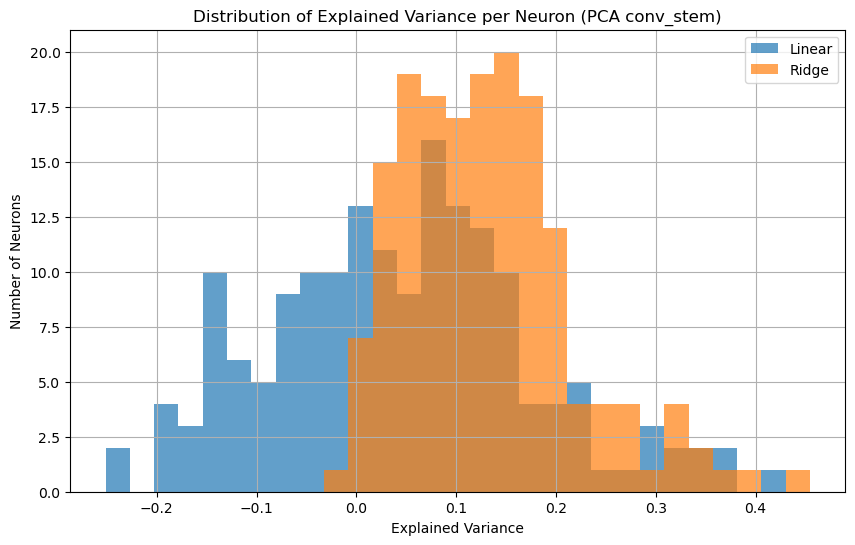

Mean correlation (linear regression): 0.3128061294555664
Mean correlation (ridge regression): 0.3531229794025421


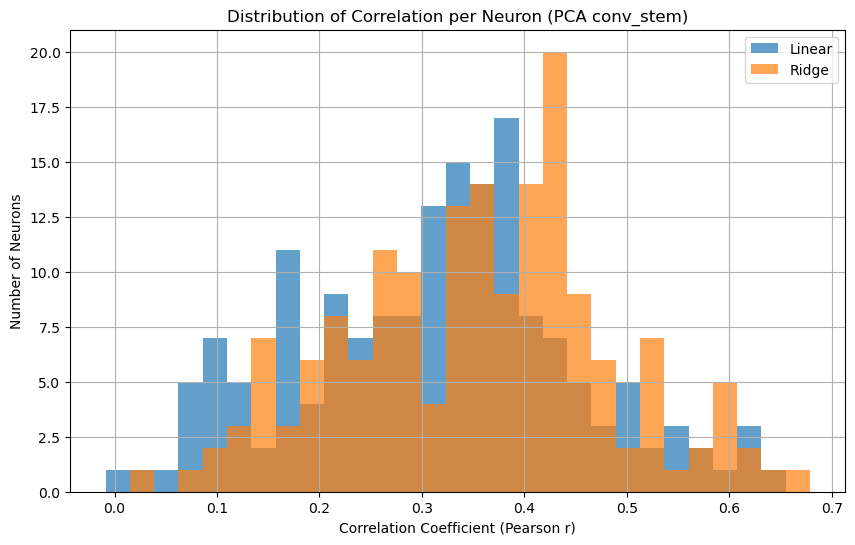


Processing block1...
Mean squared error (linear regression): 0.11841724067926407
Mean squared error (ridge regression): 0.11711213737726212
Mean explained variance (linear regression): 0.13178637623786926
Mean explained variance (ridge regression): 0.1494138538837433


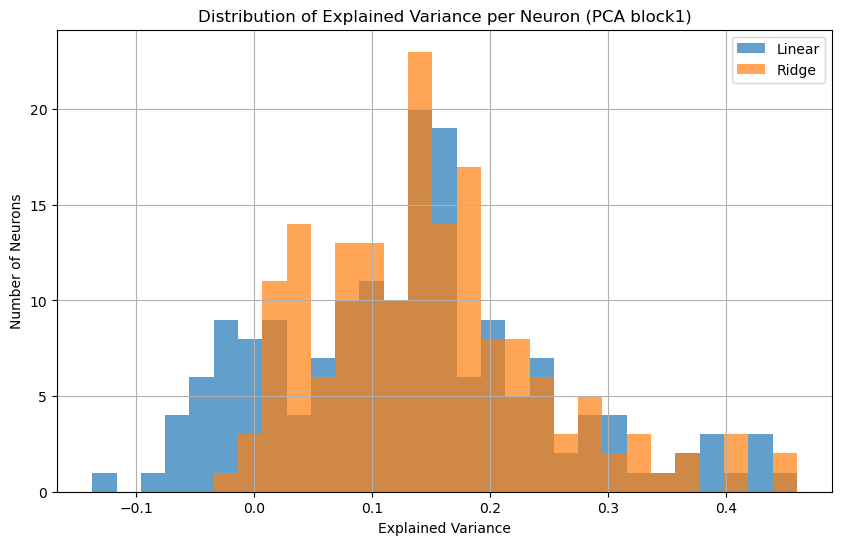

Mean correlation (linear regression): 0.361211359500885
Mean correlation (ridge regression): 0.37458091974258423


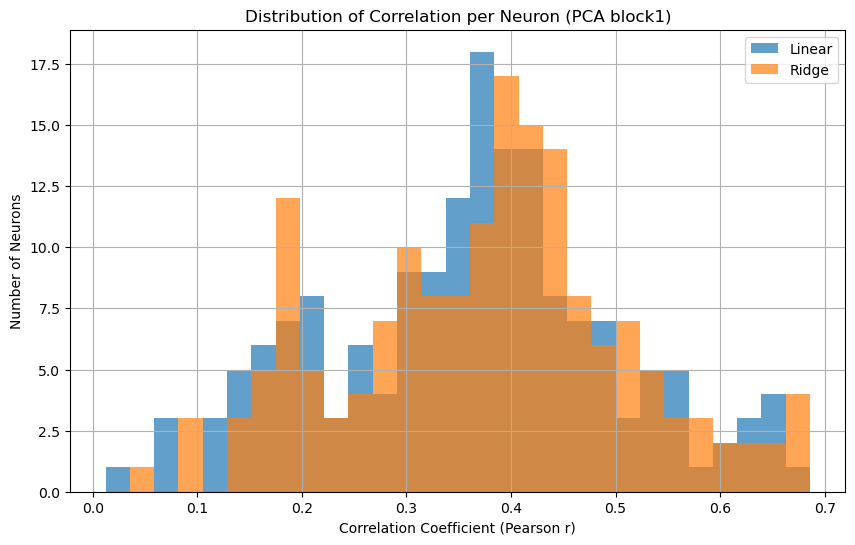


Processing block2...
Mean squared error (linear regression): 0.10674303770065308
Mean squared error (ridge regression): 0.10603469610214233
Mean explained variance (linear regression): 0.20418991148471832
Mean explained variance (ridge regression): 0.2203158140182495


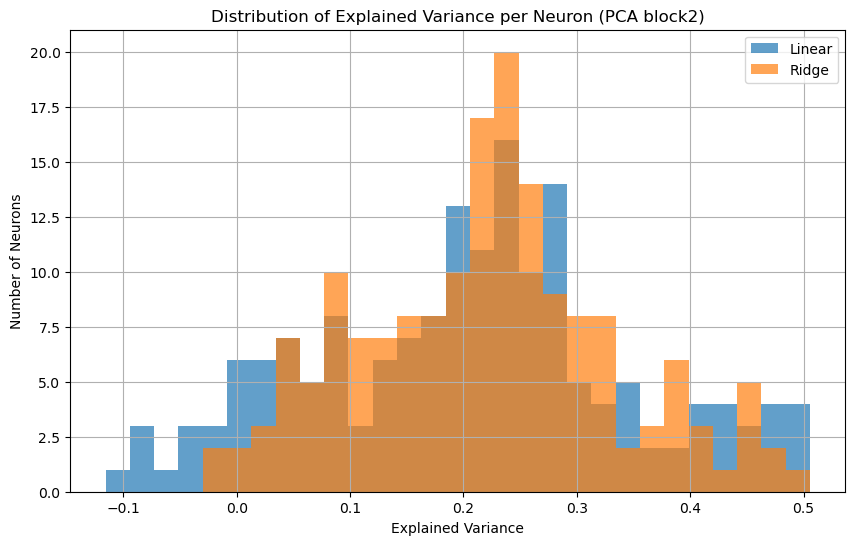

Mean correlation (linear regression): 0.4495294690132141
Mean correlation (ridge regression): 0.46292904019355774


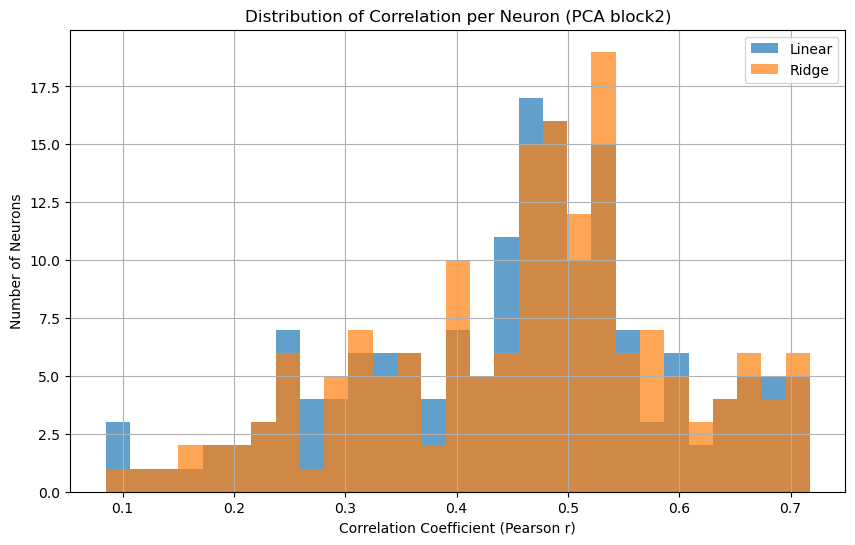


Processing block4...
Mean squared error (linear regression): 0.08481963723897934
Mean squared error (ridge regression): 0.09771712869405746
Mean explained variance (linear regression): 0.32972314953804016
Mean explained variance (ridge regression): 0.27434831857681274


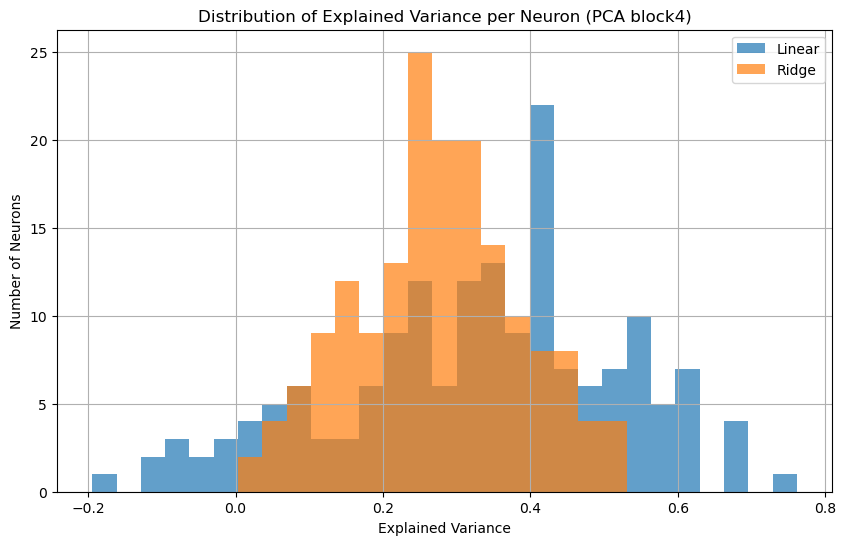

Mean correlation (linear regression): 0.5749040246009827
Mean correlation (ridge regression): 0.5667812824249268


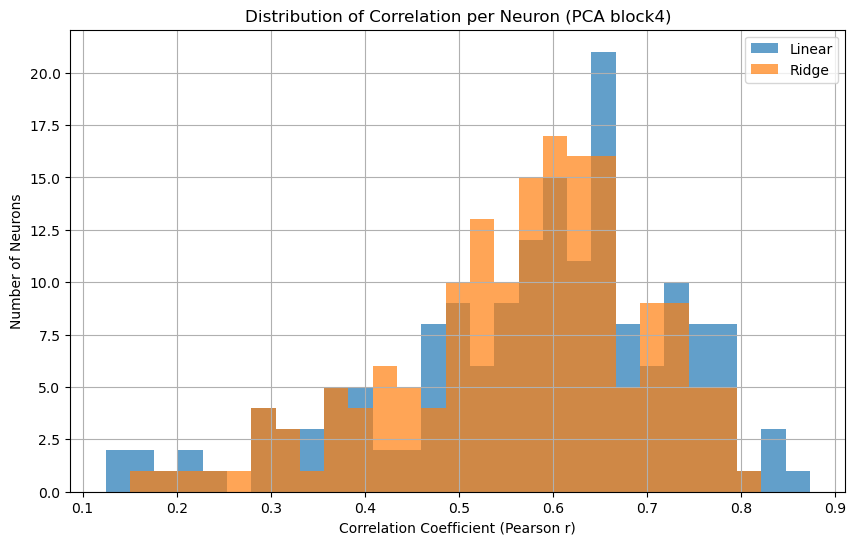


Processing block6...
Mean squared error (linear regression): 0.07857634872198105
Mean squared error (ridge regression): 0.08835642784833908
Mean explained variance (linear regression): 0.35188108682632446
Mean explained variance (ridge regression): 0.33079084753990173


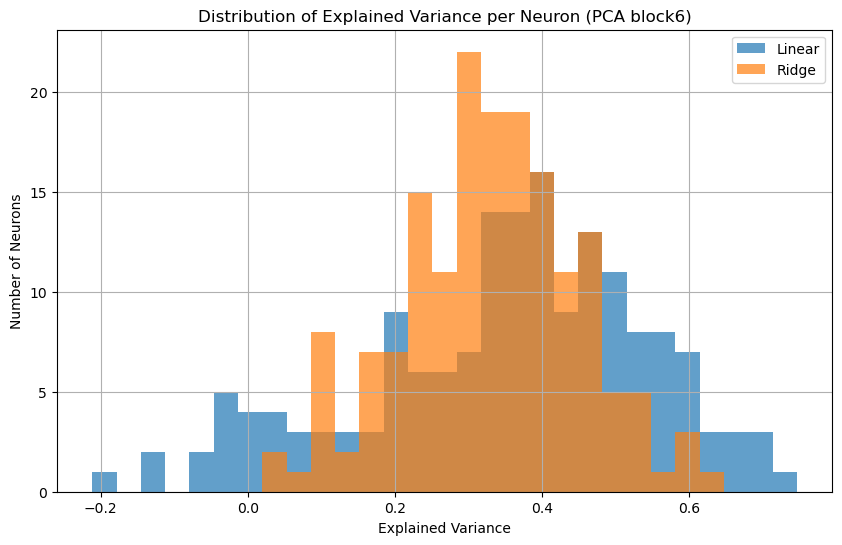

Mean correlation (linear regression): 0.6061690449714661
Mean correlation (ridge regression): 0.6070199012756348


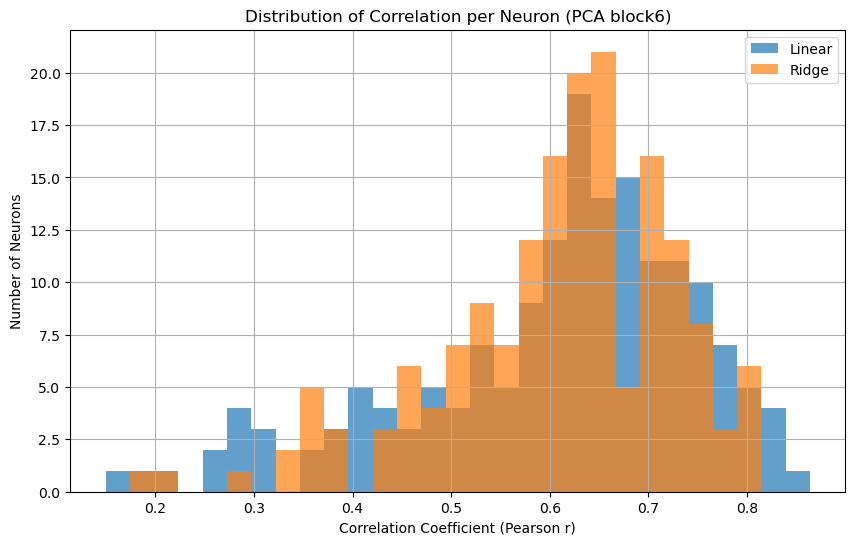


Processing avgpool...
Mean squared error (linear regression): 0.12368089705705643
Mean squared error (ridge regression): 0.14051929116249084
Mean explained variance (linear regression): 0.03974305838346481
Mean explained variance (ridge regression): 0.0027582489419728518


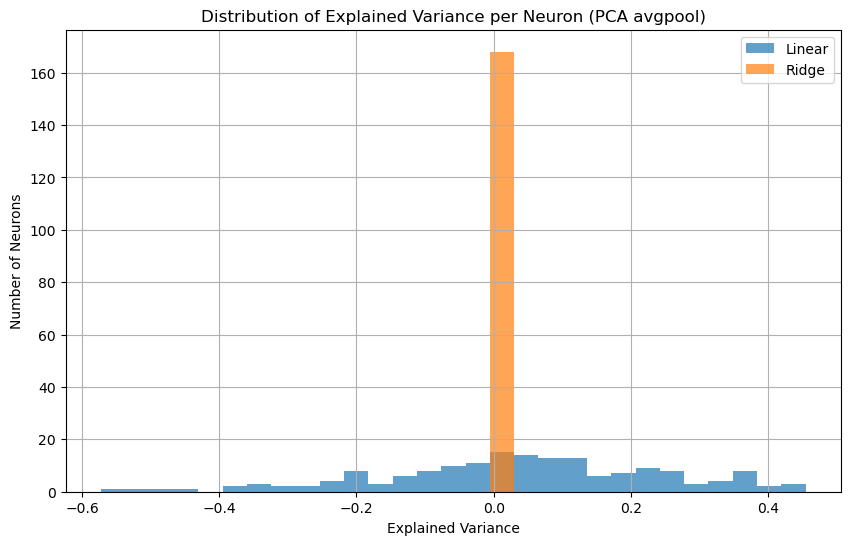

Mean correlation (linear regression): 0.4365614950656891
Mean correlation (ridge regression): 0.4265103042125702


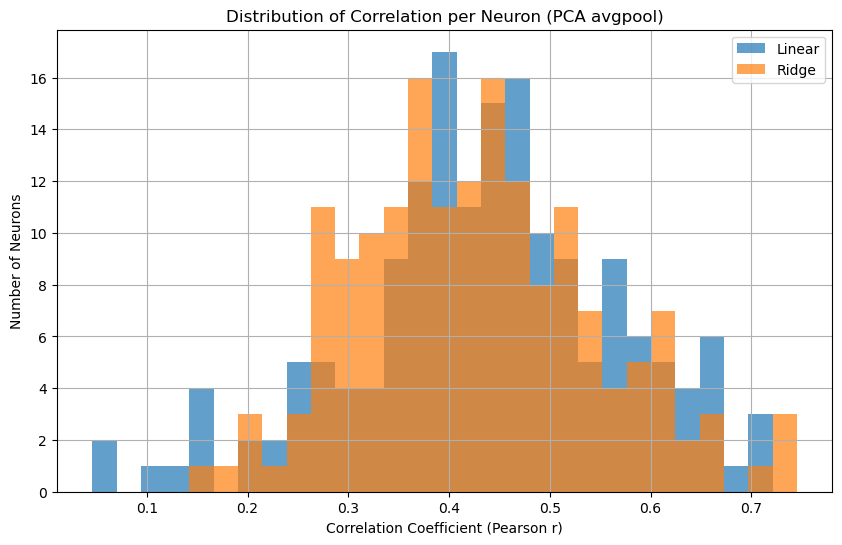


Comparison of EfficientNet Layers:
       layer    lr_mse    rr_mse     lr_ev     rr_ev   lr_corr   rr_corr
0  conv_stem  0.130468  0.120166  0.044277  0.131190  0.312806  0.353123
1     block1  0.118417  0.117112  0.131786  0.149414  0.361211  0.374581
2     block2  0.106743  0.106035  0.204190  0.220316  0.449529  0.462929
3     block4  0.084820  0.097717  0.329723  0.274348  0.574904  0.566781
4     block6  0.078576  0.088356  0.351881  0.330791  0.606169  0.607020
5    avgpool  0.123681  0.140519  0.039743  0.002758  0.436561  0.426510


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, explained_variance_score
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
from utils import load_pkl, save_pkl
from utils import load_it_data, visualize_img
import matplotlib.pyplot as plt
import numpy as np
import gdown

path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


# Load PCA-transformed activations from EfficientNet layers
X_pca_conv_stem = load_pkl("X_pca_efficientnet_conv_stem.pkl")
X_pca_block1 = load_pkl("X_pca_efficientnet_block1.pkl")
X_pca_block2 = load_pkl("X_pca_efficientnet_block2.pkl")
X_pca_block4 = load_pkl("X_pca_efficientnet_block4.pkl")
X_pca_block6 = load_pkl("X_pca_efficientnet_block6.pkl")
X_pca_avgpool = load_pkl("X_pca_efficientnet_avgpool.pkl")

# Load validation data
X_pca_conv_stem_val = load_pkl("X_pca_efficientnet_conv_stem_val.pkl")
X_pca_block1_val = load_pkl("X_pca_efficientnet_block1_val.pkl")
X_pca_block2_val = load_pkl("X_pca_efficientnet_block2_val.pkl")
X_pca_block4_val = load_pkl("X_pca_efficientnet_block4_val.pkl")
X_pca_block6_val = load_pkl("X_pca_efficientnet_block6_val.pkl")
X_pca_avgpool_val = load_pkl("X_pca_efficientnet_avgpool_val.pkl")

# Define visualization functions (same as your friend's code)
def ev_dis_plot(y_true, y_pred_lr, y_pred_rr, title='Distribution of Explained Variance per Neuron'):
    # Compute per-neuron explained variance
    lr_ev_per_neuron = explained_variance_score(y_true, y_pred_lr, multioutput='raw_values')
    rr_ev_per_neuron = explained_variance_score(y_true, y_pred_rr, multioutput='raw_values')
    
    print(f"Mean explained variance (linear regression): {np.mean(lr_ev_per_neuron)}")
    print(f"Mean explained variance (ridge regression): {np.mean(rr_ev_per_neuron)}")

    lr_ev_per_neuron.shape = (y_true.shape[1],)  # one value per neuron
    
    all_vals = np.concatenate([lr_ev_per_neuron, rr_ev_per_neuron])
    bins = np.linspace(np.min(all_vals), np.max(all_vals), 30)

    plt.figure(figsize=(10, 6))
    plt.hist(lr_ev_per_neuron, bins=bins, alpha=0.7, label='Linear')
    plt.hist(rr_ev_per_neuron, bins=bins, alpha=0.7, label='Ridge')
    plt.xlabel('Explained Variance')
    plt.ylabel('Number of Neurons')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def cor_dis_plot(y_true, y_pred_lr, y_pred_rr, title='Distribution of Correlation per Neuron'):
    cor_per_neuron = lambda y_true, y_pred: np.array([pearsonr(y_true[:, i], y_pred[:, i])[0] for i in range(y_true.shape[1])])
    lr_corr_per_neuron = cor_per_neuron(y_true, y_pred_lr)
    rr_corr_per_neuron = cor_per_neuron(y_true, y_pred_rr)
    
    print(f"Mean correlation (linear regression): {np.mean(lr_corr_per_neuron)}")
    print(f"Mean correlation (ridge regression): {np.mean(rr_corr_per_neuron)}")
    
    all_vals = np.concatenate([lr_corr_per_neuron, rr_corr_per_neuron])
    bins = np.linspace(np.min(all_vals), np.max(all_vals), 30)
    
    plt.figure(figsize=(10, 6))
    plt.hist(lr_corr_per_neuron, bins=bins, alpha=0.7, label='Linear')
    plt.hist(rr_corr_per_neuron, bins=bins, alpha=0.7, label='Ridge')
    plt.xlabel('Correlation Coefficient (Pearson r)')
    plt.ylabel('Number of Neurons')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Process each layer
def process_layer(layer_name, X_pca_train, X_pca_val, spikes_train, spikes_val, alpha=1.0):
    print(f"\nProcessing {layer_name}...")
    
    # Linear Regression
    lr_model = LinearRegression().fit(X_pca_train, spikes_train)
    lr_pred = lr_model.predict(X_pca_val)
    
    # Ridge Regression
    rr_model = Ridge(alpha=alpha).fit(X_pca_train, spikes_train)
    rr_pred = rr_model.predict(X_pca_val)
    
    # Save models and predictions
    save_pkl(lr_model, f'lr_pca_efficientnet_{layer_name}.pkl')
    save_pkl(lr_pred, f'lr_y_pred_efficientnet_{layer_name}.pkl')
    save_pkl(rr_model, f'rr_pca_efficientnet_{layer_name}.pkl')
    save_pkl(rr_pred, f'rr_y_pred_efficientnet_{layer_name}.pkl')
    
    # Evaluate
    lr_mse = mean_squared_error(spikes_val, lr_pred)
    rr_mse = mean_squared_error(spikes_val, rr_pred)
    print(f'Mean squared error (linear regression): {lr_mse}')
    print(f'Mean squared error (ridge regression): {rr_mse}')
    
    # Visualize
    ev_dis_plot(spikes_val, lr_pred, rr_pred, 
                title=f'Distribution of Explained Variance per Neuron (PCA {layer_name})')
    cor_dis_plot(spikes_val, lr_pred, rr_pred, 
                title=f'Distribution of Correlation per Neuron (PCA {layer_name})')
    
    return {
        'layer': layer_name,
        'lr_mse': lr_mse,
        'rr_mse': rr_mse,
        'lr_ev': np.mean(explained_variance_score(spikes_val, lr_pred, multioutput='raw_values')),
        'rr_ev': np.mean(explained_variance_score(spikes_val, rr_pred, multioutput='raw_values')),
        'lr_corr': np.mean([pearsonr(spikes_val[:, i], lr_pred[:, i])[0] for i in range(spikes_val.shape[1])]),
        'rr_corr': np.mean([pearsonr(spikes_val[:, i], rr_pred[:, i])[0] for i in range(spikes_val.shape[1])])
    }

# Process all layers and collect results
results = []

# You'll need to use the actual spikes data here
# Assuming spikes_train and spikes_val are already loaded
# If not, load them:
# spikes_train = load_pkl("spikes_train.pkl")
# spikes_val = load_pkl("spikes_val.pkl")

# Process each layer with appropriate ridge alpha (you may need to tune these)
results.append(process_layer('conv_stem', X_pca_conv_stem, X_pca_conv_stem_val, 
                            spikes_train, spikes_val, alpha=3114880.0))
results.append(process_layer('block1', X_pca_block1, X_pca_block1_val, 
                            spikes_train, spikes_val, alpha=3114880.0))
results.append(process_layer('block2', X_pca_block2, X_pca_block2_val, 
                            spikes_train, spikes_val, alpha=3114880.0))
results.append(process_layer('block4', X_pca_block4, X_pca_block4_val, 
                            spikes_train, spikes_val, alpha=3114880.0))
results.append(process_layer('block6', X_pca_block6, X_pca_block6_val, 
                            spikes_train, spikes_val, alpha=3114880.0))
results.append(process_layer('avgpool', X_pca_avgpool, X_pca_avgpool_val, 
                            spikes_train, spikes_val, alpha=3114880.0))

# Create a comparison table
import pandas as pd

df_results = pd.DataFrame(results)
df_results = df_results[['layer', 'lr_mse', 'rr_mse', 'lr_ev', 'rr_ev', 'lr_corr', 'rr_corr']]
print("\nComparison of EfficientNet Layers:")
print(df_results)

# Save results
df_results.to_csv('efficientnet_layer_comparison.csv', index=False)